In [55]:
import pandas as pd
cat_df = pd.read_csv("../data/raw/05_category_inflows.csv")
cat_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [56]:
cat_df.tail()

,month,category,net_inflow_crore
139,2025-03,Sectoral/Thematic,8614.0
140,2025-03,Liquid,38681.0
141,2025-03,Short Duration,4886.0
142,2025-03,Gilt,956.0
143,2025-03,Hybrid,2830.0


In [57]:
cat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


In [58]:
cat_df.shape

(144, 3)

In [59]:
cat_df.isnull().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [60]:
cat_df["category"].unique()

array(['Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap',
       'Large & Mid Cap', 'ELSS', 'Value/Contra', 'Sectoral/Thematic',
       'Liquid', 'Short Duration', 'Gilt', 'Hybrid'], dtype=object)

In [61]:
cat_df.duplicated().sum()

np.int64(0)

In [62]:
cat_df.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='object')

In [63]:
cat_df.groupby('category')['net_inflow_crore'].sum().sort_values(ascending=False)

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

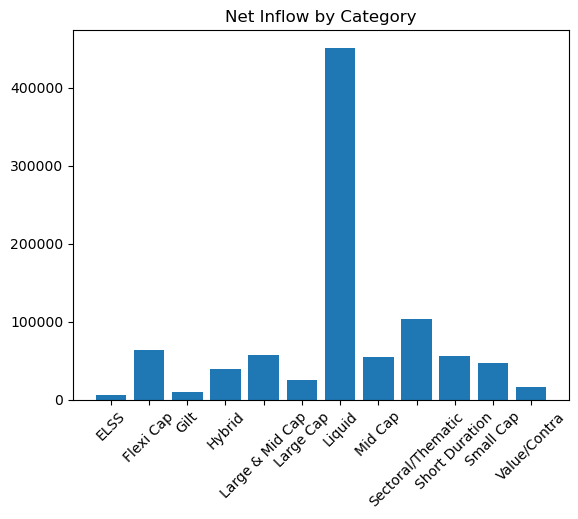

In [65]:
import matplotlib.pyplot as plt

category_data = cat_df.groupby('category')['net_inflow_crore'].sum()

plt.bar(category_data.index, category_data.values)
plt.xticks(rotation=45)
plt.title("Net Inflow by Category")
plt.show()

In [66]:
Q1 = cat_df['net_inflow_crore'].quantile(0.25)
Q3 = cat_df['net_inflow_crore'].quantile(0.75)

IQR = Q3 - Q1

In [67]:
df_clean = cat_df[
    (cat_df['net_inflow_crore'] >= Q1 - 1.5 * IQR) &
    (cat_df['net_inflow_crore'] <= Q3 + 1.5 * IQR)
]

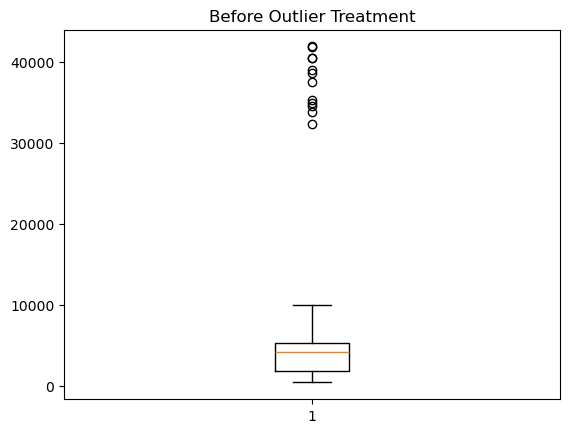

In [68]:
plt.boxplot(cat_df['net_inflow_crore'])
plt.title("Before Outlier Treatment")
plt.show()

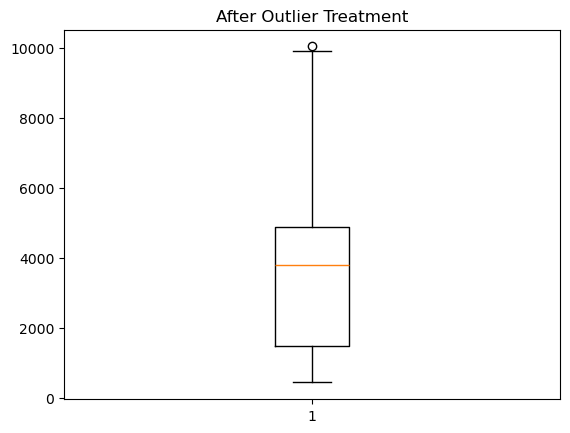

In [69]:
plt.boxplot(df_clean['net_inflow_crore'])
plt.title("After Outlier Treatment")
plt.show()

In [70]:
upper = cat_df['net_inflow_crore'].quantile(0.95)
lower = cat_df['net_inflow_crore'].quantile(0.05)

cat_df['net_inflow_crore'] = cat_df['net_inflow_crore'].clip(lower, upper)

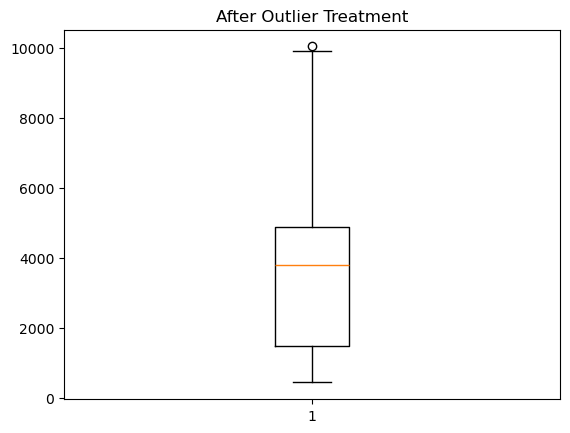

In [71]:
plt.boxplot(df_clean['net_inflow_crore'])
plt.title("After Outlier Treatment")
plt.show()

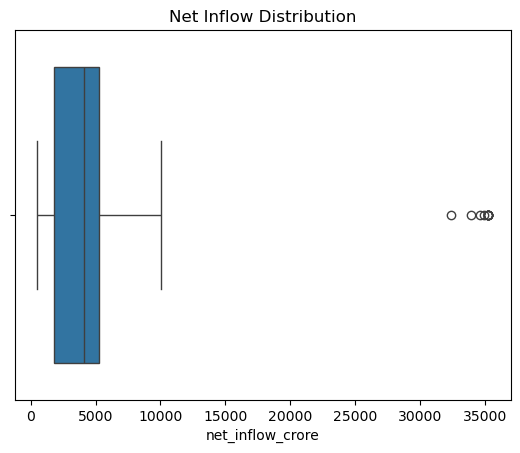

In [73]:
import seaborn as sns
sns.boxplot(x=cat_df['net_inflow_crore'])
plt.title("Net Inflow Distribution")
plt.show()